## Aux Functions

In [1]:
from pathlib import Path
from datetime import datetime
import json
import os
import shutil
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import spearmanr
from pandas import read_pickle

#### Make experiment folder

In [2]:
stamp = datetime.now().strftime("%Y_%m_%d_%H%M")
experiment_folder = Path("experiments") / stamp
experiment_folder.mkdir(parents=True, exist_ok=True)
print("Created:", experiment_folder)

Created: experiments/2026_08_20_2036


In [3]:
def dedupe_inplace(seq):
    seen = set()
    write = 0
    for item in seq:
        if item not in seen:
            seen.add(item)
            seq[write] = item
            write += 1
    del seq[write:]

In [4]:
# add simulations to list
def add(subject=None, story=None, simulations=None):
    if simulations is None:
        raise ValueError("Simulations list is required")    
    if subject is None and story is None:
        raise ValueError("Provide at least subject or story")
    # add all simulations of a subject
    if story == None:
        _add_subject(subject, simulations)
    # add all simulations of a story
    if subject == None:
        _add_story(story, simulations)
    # add simulation for a subject and story
    if subject != None and story != None:
        sim_path = _make_simulation_path(subject, story)
        if os.path.exists(sim_path):
            simulations.append(sim_path)
        else:
            raise ValueError(f"Simulation does not exist {sim_path}")
        
    dedupe_inplace(simulations)
    return simulations
        
# add all simulations of a subject
def _add_subject(subject, simulations):
    suffix = f"{subject}.tsv"
    simulations.extend(str(p) for p in Path("simulations").rglob("*.tsv")
                       if p.name.lower().endswith(suffix))

# add all simulations of a story
def _add_story(story, simulations):
    story_dir = Path("simulations") / story
    if story_dir.is_dir():
        simulations.extend(str(p) for p in story_dir.rglob("*.tsv"))


def _make_simulation_path(subject, story):
    return f'simulations/{story}/{subject}.tsv'

In [5]:
simulations_list = []

## Setup

Add simulations to the simulations_list using the add function, the possible parameter combinations :

- subject and story, to add a specific subject-story simulation
- only subject, to add all simulations for that subject
- only story, to add all simulations for that story

In [6]:
# add(subject = *, story = *, simulations=simulations_list)
# choose a subject and a story simulation or just a subject/story to add all its simulations
#add(subject='subject0', story='Axolotl', simulations=simulations_list)
#add(subject='perfil5', story='Axolotl', simulations=simulations_list)
#add(story='cuento2', simulations=simulations_list)
#add(subject='perfil4',simulations=simulations_list)
#add(story='Como_funcionan_los_bolsillos', simulations=simulations_list)

#add(subject='ob1-006', story='Como_funcionan_los_bolsillos', simulations=simulations_list)

add(subject='ob1-001', story='El_espejo', simulations=simulations_list)
for i in range(1, 19):
    subject = f"ob1-{i:03d}"
    try:
        add(subject=subject, story='El_espejo', simulations=simulations_list)
    except ValueError as e:
        print(f"Skipping {subject}: {e}")

## Experiment

### Save files used

In [7]:
out_path = Path(experiment_folder) / "simulations_list.json"
with out_path.open("w", encoding="utf-8") as f:
    json.dump(simulations_list, f, ensure_ascii=False, indent=2)

### Generate processed folder

Generates the processed folder the analysis script uses

Creates the folder

In [8]:
processed_path = "../data/processed"

if os.path.exists(processed_path):
    try:
        shutil.rmtree(processed_path)
        print(f"Folder '{processed_path}' and its contents deleted successfully.")
    except OSError as e:
        print(f"Error: {processed_path} : {e.strerror}")
else:
    print(f"Folder '{processed_path}' does not exist.")

Folder '../data/processed' and its contents deleted successfully.


In [9]:
trials_path = processed_path + '/trials'
os.makedirs(trials_path)
print(f"Folder '{trials_path}' created successfully.")

Folder '../data/processed/trials' created successfully.


Populates the folder in the correct format with the simulations in simulations_list

In [10]:
examples_directory = '../data/processed_examples'

In [11]:
import unicodedata

def normalize_story_name(story):
    return ''.join(
        char for char in unicodedata.normalize('NFKD', story)
        if not unicodedata.combining(char)
    ).casefold()

def resolve_story_key(stimuli_json, story):
    if story in stimuli_json:
        return story

    normalized_story = normalize_story_name(story)
    matches = [key for key in stimuli_json if normalize_story_name(key) == normalized_story]

    if len(matches) == 1:
        return matches[0]

    available_stories = ', '.join(sorted(stimuli_json))
    raise KeyError(f"Story '{story}' not found in stimuli JSON. Available stories: {available_stories}")

def resolve_story_directory(base_directory, story):
    source_directory = os.path.join(base_directory, story)
    if os.path.exists(source_directory):
        return source_directory

    normalized_story = normalize_story_name(story)
    matches = [
        directory for directory in os.listdir(base_directory)
        if os.path.isdir(os.path.join(base_directory, directory))
        and normalize_story_name(directory) == normalized_story
    ]

    if len(matches) == 1:
        return os.path.join(base_directory, matches[0])

    raise FileNotFoundError(f"No processed example folder found for story '{story}' in {base_directory}")

def add_screens(simulation, destination_directory, stimuli_json, story):
    story_key = resolve_story_key(stimuli_json, story)
    eye_value = 'R'
    pupil_value = -1
    df = pd.read_csv(simulation, sep="\t")

    for screen_id in range(df["text_id"].nunique()):
        df_screen = df[df["text_id"] == screen_id]
        data = []
        time_acum = 0

        # screen_index in json is 0-based
        screen_words = stimuli_json[story_key][screen_id]["words"]

        for _, row in df_screen.iterrows():
            index = row["fixation_counter"]
            t_start = time_acum
            duration = row["fixation_duration"]
            time_acum += duration

            word_idx = int(row["foveal_word_index"])
            x = screen_words[word_idx]["x"]
            y = screen_words[word_idx]["y"]

            data.append({
                "index": index,
                "eye": eye_value,
                "tStart": t_start,
                "tEnd": time_acum,
                "duration": duration,
                "xAvg": x,
                "yAvg": y,
                "pupilAvg": pupil_value
            })

        output_df = pd.DataFrame(data)
        output_dir = destination_directory + f"/screen_{screen_id+1}/fixations.pkl"
        print(output_dir)
        if os.path.exists(output_dir):
            os.remove(output_dir)
        output_df = pd.to_pickle(output_df, output_dir)

    print(f"Screens added to {destination_directory}")

In [12]:
def simulation_is_complete(simulation, stimuli_json, story):
    story_key = resolve_story_key(stimuli_json, story)
    df = pd.read_csv(simulation, sep="\t")

    expected_screens = set(range(len(stimuli_json[story_key])))

    seen_screens = set(df["text_id"].dropna().astype(int).unique())

    return expected_screens.issubset(seen_screens)

In [13]:
with open("all_stimuli.json", "r", encoding="utf-8") as f:
    all_simulations_words = json.load(f)
    
incomplete_simulations = []
    
for simulation in simulations_list:
    
    print(simulation)
    story = simulation.split("/")[1].replace("_", " ")
    story_key = resolve_story_key(all_simulations_words, story)
    print(story_key)
    subject = Path(simulation).stem.split(".")[0]
    print(subject)
    subject_path = trials_path + '/' + subject
    print(f"Processing story {story_key} for subject {subject}")
    
    os.makedirs(subject_path, exist_ok=True)
    source_directory = resolve_story_directory(examples_directory, story_key)
    destination_directory = subject_path + '/' + story_key
    
    if not simulation_is_complete(simulation, all_simulations_words, story_key):
        print(f"Skipping incomplete simulation: {subject} / {story_key}")

        if os.path.exists(destination_directory):
            shutil.rmtree(destination_directory)
            
        incomplete_simulations.append(simulation)

        continue

    try:
        shutil.copytree(source_directory, destination_directory)
        print(f"Folder '{source_directory}' successfully copied to '{destination_directory}'")
    except FileExistsError:
        print(f"Error: Destination directory '{destination_directory}' already exists.")
    except Exception as e:
        print(f"An error occurred: {e}")
    
    add_screens(simulation, destination_directory, stimuli_json=all_simulations_words, story=story_key)
    print()  
    

simulations/El_espejo/ob1-001.tsv
El espejo
ob1-001
Processing story El espejo for subject ob1-001
Folder '../data/processed_examples/El espejo' successfully copied to '../data/processed/trials/ob1-001/El espejo'
../data/processed/trials/ob1-001/El espejo/screen_1/fixations.pkl
../data/processed/trials/ob1-001/El espejo/screen_2/fixations.pkl
../data/processed/trials/ob1-001/El espejo/screen_3/fixations.pkl
../data/processed/trials/ob1-001/El espejo/screen_4/fixations.pkl
Screens added to ../data/processed/trials/ob1-001/El espejo

simulations/El_espejo/ob1-002.tsv
El espejo
ob1-002
Processing story El espejo for subject ob1-002
Folder '../data/processed_examples/El espejo' successfully copied to '../data/processed/trials/ob1-002/El espejo'
../data/processed/trials/ob1-002/El espejo/screen_1/fixations.pkl
../data/processed/trials/ob1-002/El espejo/screen_2/fixations.pkl
../data/processed/trials/ob1-002/El espejo/screen_3/fixations.pkl
../data/processed/trials/ob1-002/El espejo/screen_4

In [14]:
incomplete_simulations

[]

### Run analysis script

In [15]:
stories = []
for sim in simulations_list:
    story = sim.split('/')[1].replace('_', ' ')
    print(story)
    if story not in stories:
        stories.append(story)

El espejo
El espejo
El espejo
El espejo
El espejo
El espejo
El espejo
El espejo
El espejo
El espejo
El espejo
El espejo
El espejo
El espejo
El espejo
El espejo
El espejo
El espejo


In [16]:
%%bash
rm -rf ../results/*

In [17]:
for story in stories:
    subprocess.run(
        ["python3", "em_analysis.py", "--item", story, "--reprocess"],
        cwd="..",
        check=True
    )

Assigning fixations to words...


Processing items in parallel:   0%|          | 0/1 [00:00<?, ?it/s]

----------------
Antes
      subj  screen  line  word_pos  trial_fix  screen_fix  duration     x
0  ob1-016       1     0         0        2.0         2.0     275.0  42.0
1  ob1-016       1     0         1        1.0         1.0     325.0  21.0
2  ob1-016       1     0         1        3.0         3.0     425.0  21.0
3  ob1-016       1     0         1        5.0         5.0     425.0  21.0
4  ob1-016       1     0         2        4.0         4.0     325.0  56.0
Después
      subj  screen  line  word_pos  trial_fix  screen_fix  duration     x
0  ob1-016       1     0         0        2.0         2.0     275.0  42.0
1  ob1-016       1     0         1        NaN         NaN       NaN   NaN
2  ob1-016       1     0         1        3.0         3.0     425.0  21.0
3  ob1-016       1     0         1        5.0         5.0     425.0  21.0
4  ob1-016       1     0         2        4.0         4.0     325.0  56.0
----------------
Antes
       subj  screen  line  word_pos  trial_fix  screen_fix

Processing items in parallel:   0%|          | 0/1 [00:00<?, ?it/s]

Extracting eye-tracking measures from trials...


Processing items in parallel: 100%|██████████| 1/1 [00:56<00:00, 56.24s/it]


Analysing eye-tracking measures...
           subjs  words  words_excluded    fix  fix_excluded  regressions  skips  out_of_bounds  return_sweeps
El espejo     18    628             155  21417          5603        13051   3826             25            103
Total         18    628             155  21417          5603        13051   3826             25            103
Figure(640x480)
Figure(1400x1200)
Figure(1400x1200)
[INFO] MLM salteado: se necesitan >=2 sujetos e >=2 ítems (hay subj=18, item=1).


R[write to console]: Warning messages:

R[write to console]: 1: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages

R[write to console]: 2: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages

R[write to console]: 3: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages

R[write to console]: 4: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:

In [18]:
source_directory = "../results"
destination_directory = experiment_folder / "results"

try:
    shutil.copytree(source_directory, destination_directory)
    print(f"Folder '{source_directory}' successfully copied to '{destination_directory}'")
except FileExistsError:
    print(f"Error: Destination directory '{destination_directory}' already exists.")
except Exception as e:
    print(f"An error occurred: {e}")
    
    

Folder '../results' successfully copied to 'experiments/2026_08_20_2036/results'


## Correlations

In [19]:
# humans
measures_path_1 = Path('results_og_all_El_espejo', 'measures')
# ob1
measures_path_2 = Path(f'{experiment_folder}/results', 'measures')
# save results
measures_correlation_path = Path(experiment_folder, 'measures_correlation')
# measures to analyze
measures = ['FFD', 'FPRT', 'TFD', 'SFD', 'SPRT', 'RRT']
# number of bins
n_bins = 10

#### Aux Functions

In [20]:
def binarize_measure(subj, measure):
    measure_mask = subj[measure] > 0
    subj = subj.astype({measure: np.float32})
    subj.loc[:, measure] = pd.qcut(subj[measure][measure_mask], n_bins, labels=False,
                                   duplicates='drop')
    subj.loc[:, measure] = subj[measure].fillna(0)
    subj.loc[:, measure] = subj[measure].astype(np.int32)
    return subj

def binarize_subjects_measures(subjects, measures):
    binarized_subjects = []
    for name, subj in subjects:
        subj = subj[~subj['excluded']].copy()
        for measure in measures:
            subj = binarize_measure(subj, measure)
        binarized_subjects.append((name, subj))
    return binarized_subjects

def compute_correlation_matrices(subjects_1, subjects_2, all_measures):
    correlation_matrices = []

    for measure in all_measures:
        correlation_matrix = np.zeros((len(subjects_1), len(subjects_2)))
        for i, (name1, subj1) in enumerate(subjects_1):
            for j, (name2, subj2) in enumerate(subjects_2):
                corr = spearmanr(subj1[measure], subj2[measure])[0]
                correlation_matrix[i, j] = 0 if np.isnan(corr) else corr
        correlation_matrices.append(correlation_matrix)

    return correlation_matrices

def make_human_mean_subject(binarized_subjects_1, measures):
    mean_df = pd.DataFrame()

    for measure in measures:
        values = pd.concat(
            [subj[measure].reset_index(drop=True) for _, subj in binarized_subjects_1],
            axis=1
        )
        mean_df[measure] = values.mean(axis=1)

    return ("human_mean", mean_df)

def plot_correlation_matrices(correlation_matrices, all_measures, title, min_val=0.0, max_val=1.0, filename='global_avg'): 
    fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True, sharey=True)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    
    for i, measure in enumerate(all_measures):
        sns.heatmap(correlation_matrices[i], ax=axes[i // 3, i % 3], cmap='coolwarm', center=0,
                    vmin=min_val, vmax=max_val, cbar=(i == 0), cbar_ax=cbar_ax if i == 0 else None)
        axes[i // 3, i % 3].set_title(measure)
        axes[i // 3, i % 3].tick_params(axis='y', rotation=0)
        axes[i // 3, i % 3].tick_params(axis='x', rotation=0)
    
    if title:
        fig.suptitle(title + f' - {n_bins} bins')
    plt.subplots_adjust(right=0.9)
    
    fig.savefig(measures_correlation_path / f'{filename}.png', dpi=300)

In [21]:
def plot_individual_correlation_matrices(
    correlation_matrices,
    all_measures,
    mean_corr_df,
    subj_names_1,
    subj_names_2,
    title=None,
    min_val=0.0,
    max_val=1.0,
    filename_prefix='plot'
):

    for i, measure in enumerate(all_measures):
        fig, ax = plt.subplots(figsize=(7, 5))

        # ---- ADD COLUMN (mean correlations) ----
        extra_col = mean_corr_df[measure].values.reshape(-1, 1)
        augmented_matrix = np.concatenate(
            [correlation_matrices[i], extra_col],
            axis=1
        )

        # ---- LABELS ----
        xticklabels = list(subj_names_2) + ['human_corr_mean']
        yticklabels = subj_names_1

        sns.heatmap(
            augmented_matrix,
            ax=ax,
            cmap='coolwarm',
            center=0,
            vmin=min_val,
            vmax=max_val,
            cbar=True,
            xticklabels=xticklabels,
            yticklabels=yticklabels
        )

        # ---- HIGHLIGHT separator ----
        ax.axvline(
            x=correlation_matrices[i].shape[1],
            color='black',
            linewidth=2
        )

        # ---- TITLES / FORMATTING ----
        ax.set_title(measure if title is None else f'{title} - {measure}')
        ax.set_xlabel('OB1 subjects')
        ax.set_ylabel('Human subjects')

        ax.tick_params(axis='y', rotation=0)
        ax.tick_params(axis='x', rotation=90)
        
        ax.set_yticklabels(yticklabels, fontsize=6)
        ax.set_xticklabels(xticklabels, fontsize=6)

        plt.tight_layout()

        # ---- SAVE ----
        safe_measure = measure.replace(" ", "_").replace("/", "_")
        safe_prefix = filename_prefix.replace(" ", "_").replace("/", "_")

        fig.savefig(
            measures_correlation_path / f'{safe_prefix}_{safe_measure}.png',
            dpi=300
        )

        plt.show()
        plt.close(fig)

In [22]:
leave_out_subj = [
    "sub-020",
    "sub-113",
    "sub-029",
    "sub-069",
    "sub-031",
    "sub-087",
    "sub-054",
    "sub-085",
    "sub-077",
    "sub-060",
    "sub-097",
    "sub-070",
    "sub-053",
    "sub-036",
    "sub-065",
    "sub-039",
    "sub-111",
    "sub-003",
    "sub-013",
    "sub-066",
    "sub-091",
    "sub-018",
    "sub-052",
]
len(leave_out_subj)

23

### Code

In [23]:
items_1 = list(measures_path_1.iterdir())
items_2 = list(measures_path_2.iterdir())
item_subj_1 = {item.name: list(item.iterdir()) for item in items_1}
item_subj_2 = {item.name: list(item.iterdir()) for item in items_2}
common_items = set(item_subj_1.keys()) & set(item_subj_2.keys())
measures_correlation_path.mkdir(parents=True, exist_ok=True)

In [24]:
len(item_subj_1["El espejo"])

56

In [25]:
for item, paths in item_subj_1.items():
    item_subj_1[item] = [p for p in paths if p.stem not in leave_out_subj]

In [26]:
len(item_subj_1["El espejo"])

39

In [27]:
items_correlation_matrices = {}
items_subject_names = {}
for item in common_items:
    subjects_1 = [(subj_path.stem, read_pickle(subj_path)) for subj_path in item_subj_1[item]]
    subjects_2 = [(subj_path.stem, read_pickle(subj_path)) for subj_path in item_subj_2[item]]
    binarized_subjects_1 = binarize_subjects_measures(subjects_1, measures)
    binarized_subjects_2 = binarize_subjects_measures(subjects_2, measures)
    human_mean_subject = make_human_mean_subject(binarized_subjects_1, measures)
    binarized_subjects_2 = binarized_subjects_2 + [human_mean_subject]
    correlation_matrices = compute_correlation_matrices(binarized_subjects_1, binarized_subjects_2, measures)
    items_correlation_matrices[item] = correlation_matrices
    items_subject_names[item] = {
        "subjects_1": [name for name, _ in binarized_subjects_1],
        "subjects_2": [name for name, _ in binarized_subjects_2],
    }

/tmp/ipykernel_27300/2172821673.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(subj1[measure], subj2[measure])[0]


In [28]:
rows = []

for item in items_correlation_matrices:
    correlation_matrices = items_correlation_matrices[item]

    subj_names_1 = items_subject_names[item]["subjects_1"]
    subj_names_2 = items_subject_names[item]["subjects_2"]

    for m_idx, measure in enumerate(measures):
        mat = correlation_matrices[m_idx]

        for i, name1 in enumerate(subj_names_1):
            for j, name2 in enumerate(subj_names_2):
                rows.append({
                    "item": item,
                    "subject_1": name1,
                    "subject_2": name2,
                    "measure": measure,
                    "correlation": mat[i, j]
                })

df_corr = pd.DataFrame(rows)

In [29]:
mapping_rows = []

for item in items_subject_names:
    for i, name in enumerate(items_subject_names[item]["subjects_1"]):
        mapping_rows.append({
            "item": item,
            "dataset": "dataset_1",
            "index": i,
            "subject_name": name
        })

    for j, name in enumerate(items_subject_names[item]["subjects_2"]):
        mapping_rows.append({
            "item": item,
            "dataset": "dataset_2",
            "index": j,
            "subject_name": name
        })

mapping_df = pd.DataFrame(mapping_rows)

In [30]:
df_corr.to_csv(measures_correlation_path / 'correlation_results.csv', index=False)
mapping_df.to_csv(measures_correlation_path / 'subject_mapping.csv', index=False)

### Final correlations

In [31]:
df_corr[df_corr['measure'] == 'FFD'].sort_values(by=['correlation'], ascending=False)

,item,subject_1,subject_2,measure,correlation
132,El espejo,sub-109,human_mean,FFD,0.681657
588,El espejo,sub-096,human_mean,FFD,0.620889
265,El espejo,sub-044,human_mean,FFD,0.598281
740,El espejo,sub-068,human_mean,FFD,0.573124
75,El espejo,sub-079,human_mean,FFD,0.572566
...,...,...,...,...,...
510,El espejo,sub-010,ob1-009,FFD,-0.042368
427,El espejo,sub-075,ob1-005,FFD,-0.042917
329,El espejo,sub-016,ob1-011,FFD,-0.062469
54,El espejo,sub-046,ob1-009,FFD,-0.073962


In [32]:
name, subj = subjects_1[0]

test = subj[~subj['excluded']].copy()

print("before:")
print(test[measures].head())

for measure in measures:
    test = binarize_measure(test, measure)

print("after:")
print(test[measures].head())

before:
   FFD  FPRT  TFD  SFD  SPRT  RRT
1    0     0  323    0   323    0
2  148   296  296    0     0    0
3    0     0  337    0   337    0
6  136   273  273    0     0    0
7    0     0    0    0     0    0
after:
   FFD  FPRT  TFD  SFD  SPRT  RRT
1  0.0   0.0  7.0  0.0   8.0  0.0
2  1.0   7.0  7.0  0.0   0.0  0.0
3  0.0   0.0  8.0  0.0   8.0  0.0
6  1.0   6.0  6.0  0.0   0.0  0.0
7  0.0   0.0  0.0  0.0   0.0  0.0


### All plots

In [33]:
import pickle

with open(f"all_items_mean_corr.pkl", "rb") as f:
    all_items_mean_corr = pickle.load(f)

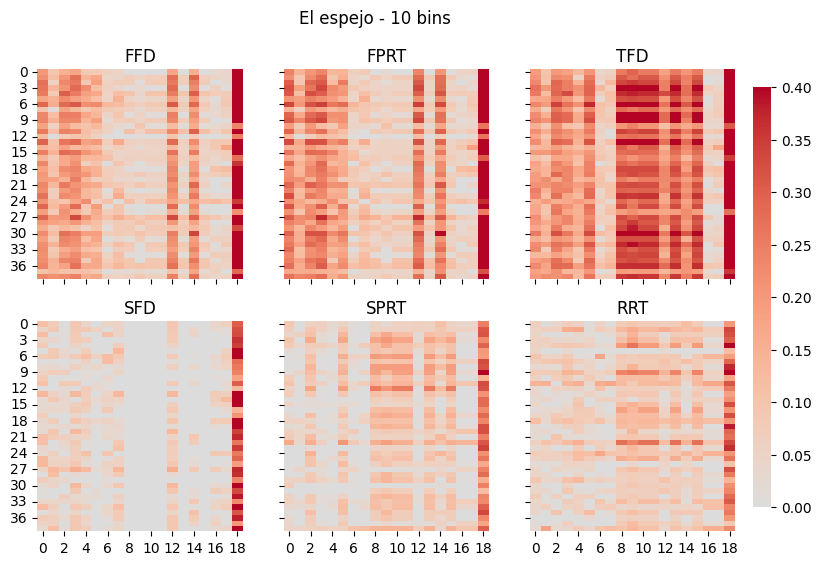

In [34]:
for item in items_correlation_matrices:
    correlation_matrices = items_correlation_matrices[item]

    plot_correlation_matrices(
        correlation_matrices,
        measures,
        title=item,
        min_val=0.0,
        max_val=0.4,
        filename=f"{item}"
    )

### Individual plots

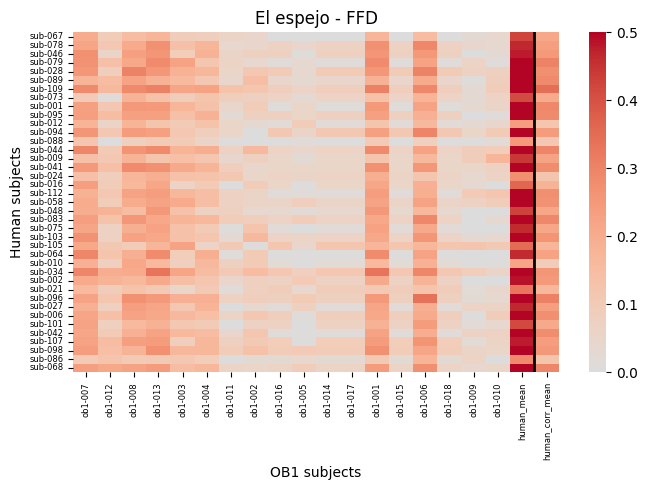

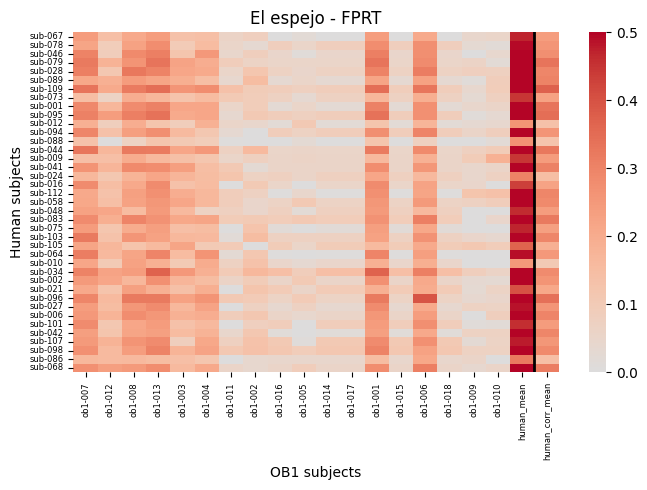

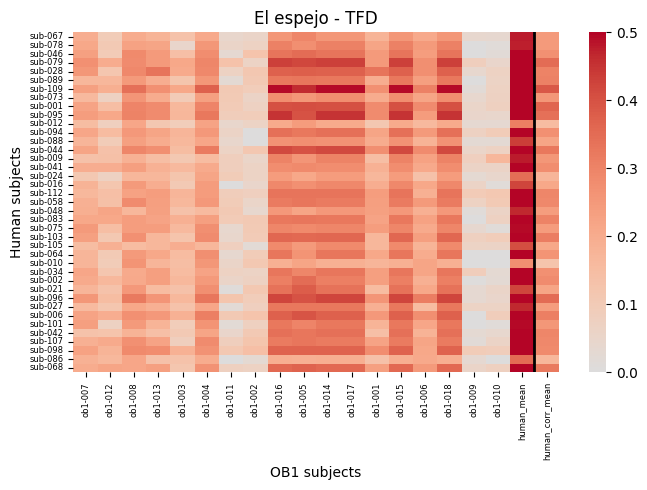

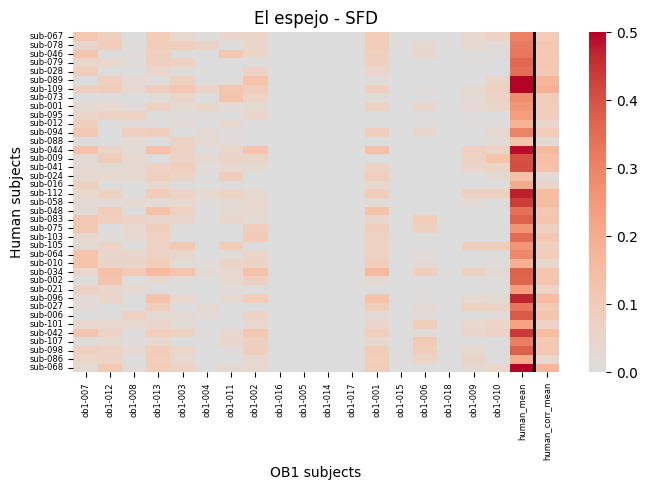

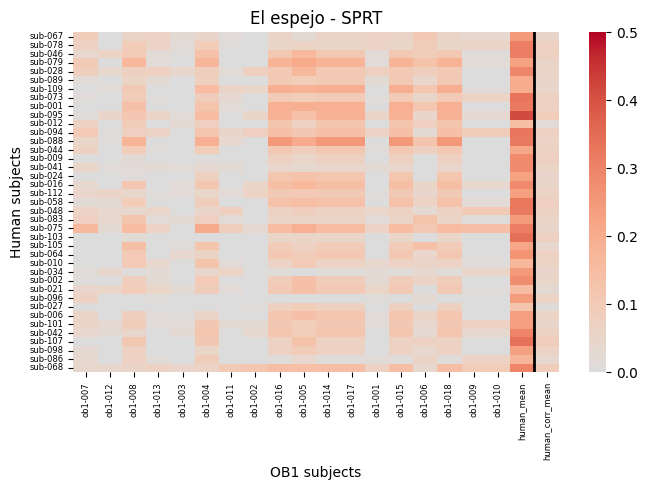

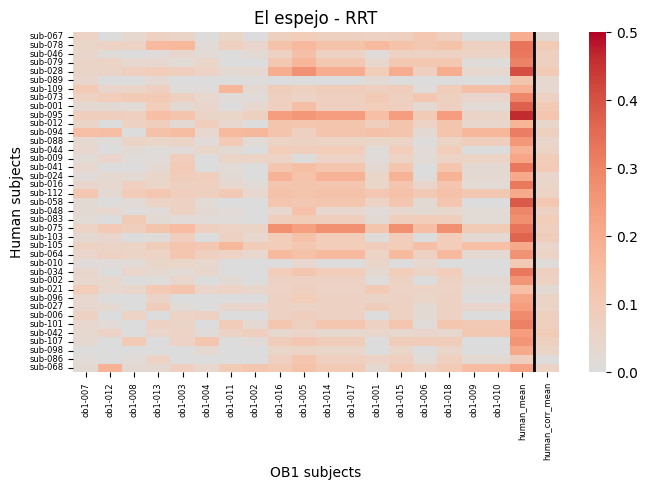

In [35]:
for item in items_correlation_matrices:
    correlation_matrices = items_correlation_matrices[item]
    safe_item = item.replace(" ", "_").replace("/", "_")

    mean_df = all_items_mean_corr[item]

    # Make sure mean_df is ordered according to subj_names_1
    if set(subj_names_1) != set(mean_df.index):
       raise ValueError(f"Subjects mismatch in item {item}")
    mean_df = mean_df.loc[subj_names_1]

    plot_individual_correlation_matrices(
        correlation_matrices,
        measures,
        mean_df,
        subj_names_1,
        subj_names_2,
        title=item,
        min_val=0.0,
        max_val=0.5,
        filename_prefix=safe_item
    )

In [36]:
# def plot_clustered_correlation_matrices(
#     correlation_matrices,
#     all_measures,
#     mean_corr_df,
#     subj_names_1,
#     subj_names_2,
#     title=None,
#     min_val=0.0,
#     max_val=1.0,
#     filename_prefix='plot'
# ):
#     import numpy as np
#     import seaborn as sns
#     import matplotlib.pyplot as plt

#     # ---- ALIGN mean_corr_df ----
#     if set(subj_names_1) != set(mean_corr_df.index):
#         raise ValueError("Subjects mismatch between matrix and mean_corr_df")

#     mean_corr_df = mean_corr_df.loc[subj_names_1]

#     for i, measure in enumerate(all_measures):
#         fig, ax = plt.subplots(figsize=(7, 5))

#         # ---- CLUSTER (on original matrix only) ----
#         cluster = sns.clustermap(
#             correlation_matrices[i],
#             cmap='coolwarm',
#             center=0,
#             vmin=min_val,
#             vmax=max_val,
#             row_cluster=True,
#             col_cluster=True,
#             xticklabels=subj_names_2,
#             yticklabels=subj_names_1,
#             figsize=(6, 6)
#         )

#         row_order = cluster.dendrogram_row.reordered_ind
#         col_order = cluster.dendrogram_col.reordered_ind

#         plt.close()  # prevent showing intermediate cluster plot

#         # ---- REORDER MATRIX ----
#         reordered_matrix = correlation_matrices[i][row_order][:, col_order]

#         # ---- ADD COLUMN (mean correlations per human subject) ----
#         extra_col = mean_corr_df[measure].values.reshape(-1, 1)
#         extra_col = extra_col[row_order]

#         augmented_matrix = np.concatenate(
#             [reordered_matrix, extra_col],
#             axis=1
#         )

#         # ---- COLUMN MEANS (OB1 subjects) ----
#         col_means = reordered_matrix.mean(axis=0)
#         col_means_str = [f"{m:.2f}" for m in col_means]

#         # ---- EXTRA COLUMN MEAN ----
#         extra_mean = extra_col.mean()
#         extra_label = f"human_corr_mean ({extra_mean:.2f})"

#         # ---- LABELS ----
#         base_labels = list(np.array(subj_names_2)[col_order])

#         xticklabels = [
#             f"{name} ({mean})"
#             for name, mean in zip(base_labels, col_means_str)
#         ] + [extra_label]

#         yticklabels = list(np.array(subj_names_1)[row_order])

#         # ---- HEATMAP ----
#         sns.heatmap(
#             augmented_matrix,
#             ax=ax,
#             cmap='coolwarm',
#             center=0,
#             vmin=min_val,
#             vmax=max_val,
#             cbar=True,
#             xticklabels=xticklabels,
#             yticklabels=yticklabels
#         )

#         # ---- HIGHLIGHT separator ----
#         ax.axvline(
#             x=reordered_matrix.shape[1],
#             color='black',
#             linewidth=2
#         )

#         # ---- TITLES / FORMATTING ----
#         ax.set_title(measure if title is None else f'{title} - {measure}')
#         ax.set_xlabel('OB1 subjects')
#         ax.set_ylabel('Human subjects')

#         ax.tick_params(axis='y', rotation=0)
#         ax.tick_params(axis='x', rotation=90)

#         ax.set_yticklabels(yticklabels, fontsize=6)
#         ax.set_xticklabels(xticklabels, fontsize=6)

#         plt.tight_layout()

#         # ---- SAVE ----
#         safe_measure = measure.replace(" ", "_").replace("/", "_")
#         safe_prefix = filename_prefix.replace(" ", "_").replace("/", "_")

#         fig.savefig(
#             measures_correlation_path / f'{safe_prefix}_{safe_measure}.png',
#             dpi=300
#         )

#         plt.show()
#         plt.close(fig)

In [37]:
def plot_clustered_correlation_matrices(
    correlation_matrices,
    all_measures,
    mean_corr_df,
    subj_names_1,
    subj_names_2,
    title=None,
    min_val=0.0,
    max_val=1.0,
    filename_prefix='plot'
):
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    # ---- ALIGN mean_corr_df ----
    if set(subj_names_1) != set(mean_corr_df.index):
        raise ValueError("Subjects mismatch between matrix and mean_corr_df")

    mean_corr_df = mean_corr_df.loc[subj_names_1]

    for i, measure in enumerate(all_measures):
        fig, ax = plt.subplots(figsize=(7, 5))

        matrix = correlation_matrices[i]
        subj_names_2_arr = np.array(subj_names_2)

        # ---- SPECIAL MATRIX COLUMNS TO KEEP OUT OF CLUSTERING ----
        matrix_special_cols = ["ob1-001", "human_mean"]

        matrix_special_idx = [
            np.where(subj_names_2_arr == col)[0][0]
            for col in matrix_special_cols
            if col in subj_names_2_arr
        ]

        cluster_idx = [
            j for j in range(len(subj_names_2_arr))
            if j not in matrix_special_idx
        ]

        cluster_matrix = matrix[:, cluster_idx]

        # ---- CLUSTER ONLY REGULAR OB1 COLUMNS ----
        cluster = sns.clustermap(
            cluster_matrix,
            cmap='coolwarm',
            center=0,
            vmin=min_val,
            vmax=max_val,
            row_cluster=True,
            col_cluster=True,
            xticklabels=subj_names_2_arr[cluster_idx],
            yticklabels=subj_names_1,
            figsize=(6, 6)
        )

        row_order = cluster.dendrogram_row.reordered_ind
        cluster_col_order = [
            cluster_idx[j]
            for j in cluster.dendrogram_col.reordered_ind
        ]
        
        # ---- FORCE HIGHEST CORRELATION COLUMNS TO THE RIGHT ----
        cluster_col_order = sorted(
            cluster_col_order,
            key=lambda j: matrix[row_order][:, j].mean()
        )

        plt.close()

        # ---- REORDER REGULAR CLUSTERED MATRIX ----
        reordered_cluster_matrix = matrix[row_order][:, cluster_col_order]

        # ---- SPECIAL COLUMNS IN REQUIRED ORDER ----
        ordered_blocks = [reordered_cluster_matrix]
        ordered_labels = list(subj_names_2_arr[cluster_col_order])

        # ob1-001
        if "ob1-001" in subj_names_2_arr:
            ob1_001_idx = np.where(subj_names_2_arr == "ob1-001")[0][0]
            ob1_001_col = matrix[row_order][:, ob1_001_idx].reshape(-1, 1)

            ordered_blocks.append(ob1_001_col)
            ordered_labels.append("ob1-001")

        # human_corr_mean
        human_corr_mean_col = mean_corr_df[measure].values.reshape(-1, 1)
        human_corr_mean_col = human_corr_mean_col[row_order]

        ordered_blocks.append(human_corr_mean_col)
        ordered_labels.append("human_corr_mean")

        # human_mean
        if "human_mean" in subj_names_2_arr:
            human_mean_idx = np.where(subj_names_2_arr == "human_mean")[0][0]
            human_mean_col = matrix[row_order][:, human_mean_idx].reshape(-1, 1)

            ordered_blocks.append(human_mean_col)
            ordered_labels.append("human_mean")

        augmented_matrix = np.concatenate(ordered_blocks, axis=1)

        # ---- LABELS WITH COLUMN MEANS ----
        col_means = augmented_matrix.mean(axis=0)

        xticklabels = [
            f"{name} ({mean:.2f})"
            for name, mean in zip(ordered_labels, col_means)
        ]

        yticklabels = list(np.array(subj_names_1)[row_order])

        # ---- HEATMAP ----
        sns.heatmap(
            augmented_matrix,
            ax=ax,
            cmap='coolwarm',
            center=0,
            vmin=min_val,
            vmax=max_val,
            cbar=True,
            xticklabels=xticklabels,
            yticklabels=yticklabels
        )

        # ---- SEPARATORS ----
        # before ob1-001 / human_corr_mean / human_mean block
        ax.axvline(
            x=reordered_cluster_matrix.shape[1],
            color='black',
            linewidth=2
        )

        # between ob1-001 and human_corr_mean
        if "ob1-001" in ordered_labels:
            ax.axvline(
                x=ordered_labels.index("human_corr_mean"),
                color='black',
                linewidth=2
            )

        # between human_corr_mean and human_mean
        if "human_mean" in ordered_labels:
            ax.axvline(
                x=ordered_labels.index("human_mean"),
                color='black',
                linewidth=2
            )

        # ---- TITLES / FORMATTING ----
        ax.set_title(measure if title is None else f'{title} - {measure}')
        ax.set_xlabel('OB1 subjects')
        ax.set_ylabel('Human subjects')

        ax.tick_params(axis='y', rotation=0)
        ax.tick_params(axis='x', rotation=90)

        ax.set_yticklabels(yticklabels, fontsize=6)
        ax.set_xticklabels(xticklabels, fontsize=6)

        plt.tight_layout()

        # ---- SAVE ----
        safe_measure = measure.replace(" ", "_").replace("/", "_")
        safe_prefix = filename_prefix.replace(" ", "_").replace("/", "_")

        fig.savefig(
            measures_correlation_path / f'{safe_prefix}_{safe_measure}.png',
            dpi=300
        )

        plt.show()
        plt.close(fig)

# Plots

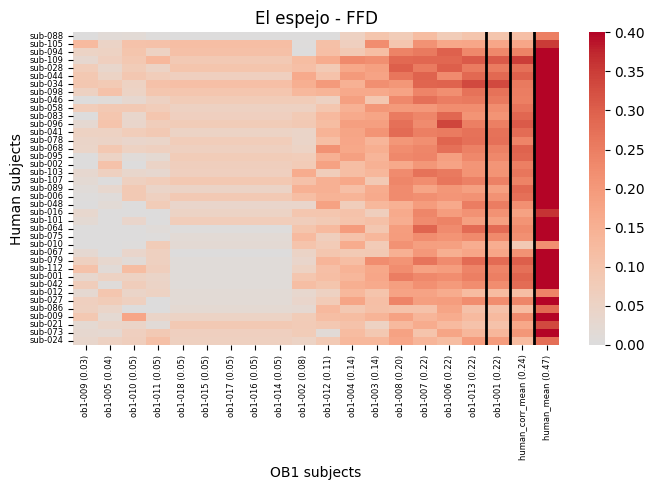

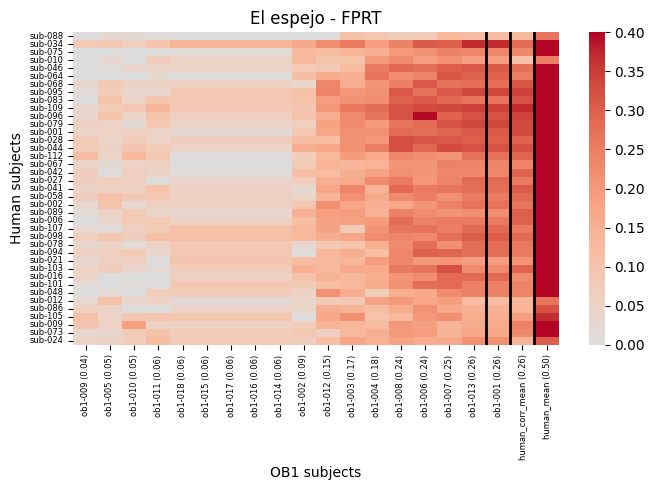

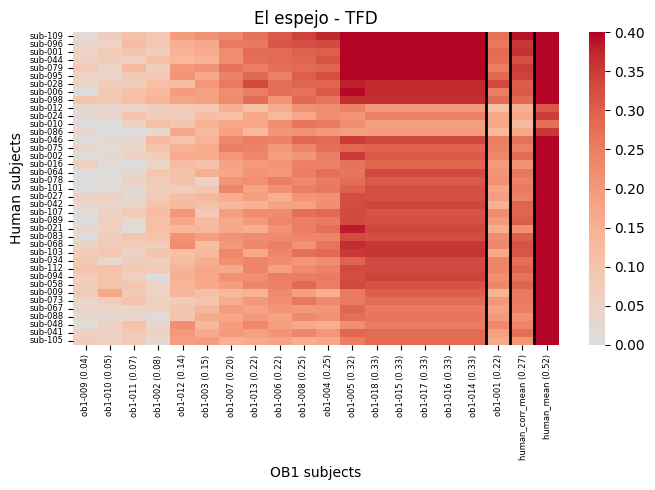

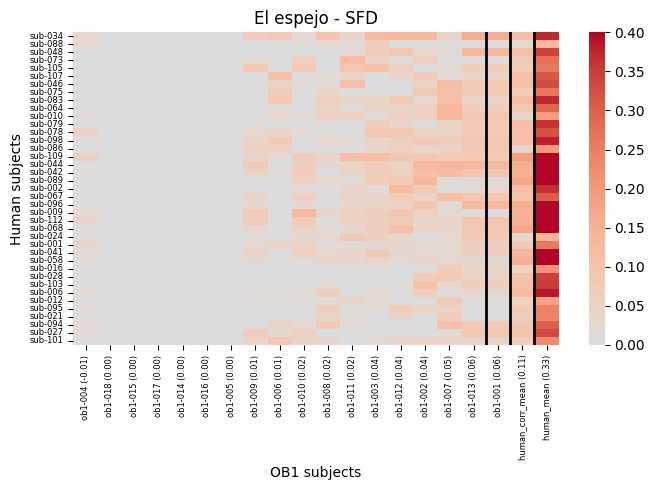

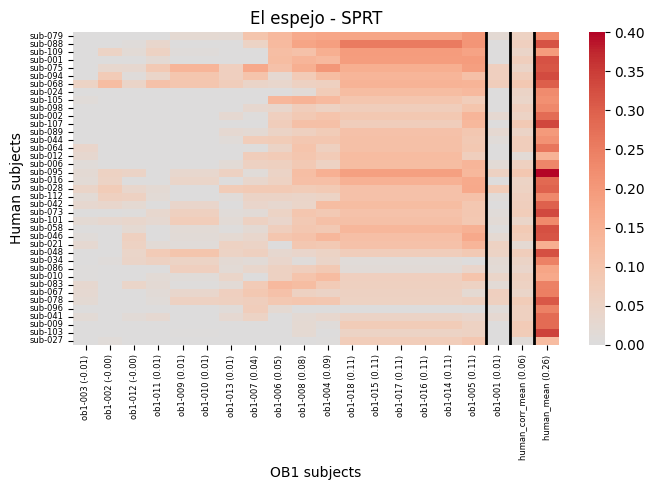

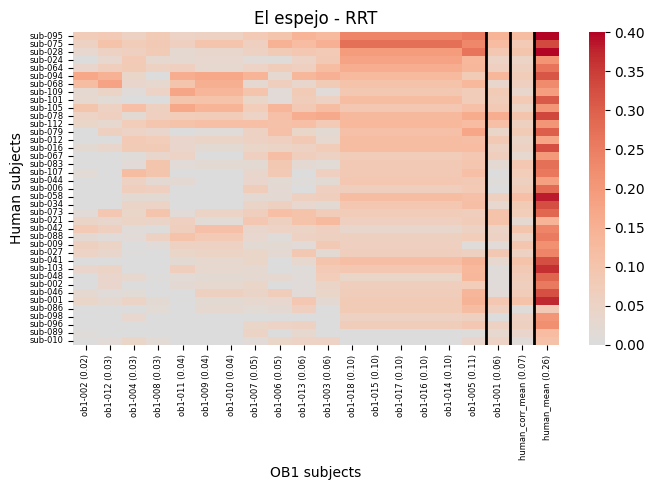

In [38]:
for item in items_correlation_matrices:
    correlation_matrices = items_correlation_matrices[item]
    safe_item = item.replace(" ", "_").replace("/", "_")

    mean_df = all_items_mean_corr[item]

    plot_clustered_correlation_matrices(
        correlation_matrices,
        measures,
        mean_df,
        subj_names_1,
        subj_names_2,
        title=item,
        min_val=0.0,
        max_val=0.4,
        filename_prefix=safe_item
    )
    

### Mumber mappings

In [39]:
mapping_df.sort_values(by='dataset', ascending=False)

,item,dataset,index,subject_name
57,El espejo,dataset_2,18,human_mean
48,El espejo,dataset_2,9,ob1-005
39,El espejo,dataset_2,0,ob1-007
40,El espejo,dataset_2,1,ob1-012
41,El espejo,dataset_2,2,ob1-008
42,El espejo,dataset_2,3,ob1-013
43,El espejo,dataset_2,4,ob1-003
45,El espejo,dataset_2,6,ob1-011
46,El espejo,dataset_2,7,ob1-002
47,El espejo,dataset_2,8,ob1-016
